Script to interpolate ice shelf mask at different resolutions for ismip7

created by ronja.reese@northumbria.ac.uk

In [1]:
import xarray as xr
import os

In [2]:
data_dir = '/media/NAS2/ISMIP7/share_with_modellers/'

In [3]:
# Load bedmap
bed = xr.load_dataset(os.path.join(data_dir, "topography", "bedmap3.nc"))

In [4]:
shelfmask = (bed.mask==3).astype('int')

In [7]:
shelfmask

<xarray.DataArray 'mask' (y: 13334, x: 13334)> Size: 1GB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * x        (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06 3.333e+06
  * y        (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06 -3.333e+06

In [9]:
alternative_grid

<xarray.Dataset> Size: 3GB
Dimensions:          (x: 6081, y: 6081, nv4: 4)
Coordinates:
  * x                (x) float64 49kB -3.04e+06 -3.039e+06 ... 3.04e+06
  * y                (y) float64 49kB -3.04e+06 -3.039e+06 ... 3.04e+06
    lon              (y, x) float64 296MB ...
    lat              (y, x) float64 296MB ...
Dimensions without coordinates: nv4
Data variables:
    ocean_kill_mask  (y, x) int8 37MB ...
    mapping          |S1 1B ...
    lon_bnds         (y, x, nv4) float64 1GB ...
    lat_bnds         (y, x, nv4) float64 1GB ...
Attributes:
    comments:     Thanks to Uwe Schulzweida (MPI) for hints on how to create ...
    Conventions:  CF-1.4
    history:      Thu Mar 12 16:46:54 2026 : grid info for CDO added by nc2cd...
    proj4:        +proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +...

In [6]:
shelfmask.coarsen(x=2, y=2, boundary="trim").mean()

<xarray.DataArray 'mask' (y: 6667, x: 6667)> Size: 356MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * x        (x) float32 27kB -3.333e+06 -3.332e+06 ... 3.332e+06 3.333e+06
  * y        (y) float32 27kB 3.333e+06 3.332e+06 ... -3.332e+06 -3.333e+06

In [26]:
alternative_grid = xr.open_dataset('/media/NAS2/pism-ais/pism_input_data/cdo_remapgrids/ismip8km.nc')

In [ ]:
shelfmask_other = shelfmask.interp_like(alternative_grid, method='linear')

In [ ]:
(shelfmask_other>0.5).plot()

In [8]:
for grid in ['1km']: #,'2km', '4km', '8km','16km', '32km', '64km' ]:
    print(grid)
    alternative_grid = xr.open_dataset('/media/NAS2/pism-ais/pism_input_data/cdo_remapgrids/ismip'+grid+'.nc')
    
    shelfmask_other = shelfmask.interp_like(alternative_grid, method='nearest')
    shelfmask_other.assign_attrs(description='shelfmask remapped from 8km to '+grid+' using nearest neighbor.')
    
    # Save as NetCDF
    #shelfmask_other.to_netcdf(data_dir+'parameterisations/floatingmasks/floatingmask_ismip'+grid+'.nc')

1km


In [30]:
bed8km = xr.load_dataset(os.path.join(data_dir, "topography", "bedmap3_ismip_8km.nc"))

In [31]:
shelfmask_8km = (bed8km.floating_frac>0.5).astype('int')
xy_coords = xr.open_dataset(data_dir+'/ismip/ismip_8km_60m_grid.nc')
shelfmask_8km = shelfmask_8km.assign_coords(x=xy_coords.x.values)
shelfmask_8km = shelfmask_8km.assign_coords(y=xy_coords.y.values)

In [ ]:
(shelfmask_8km-shelfmask_other).plot()

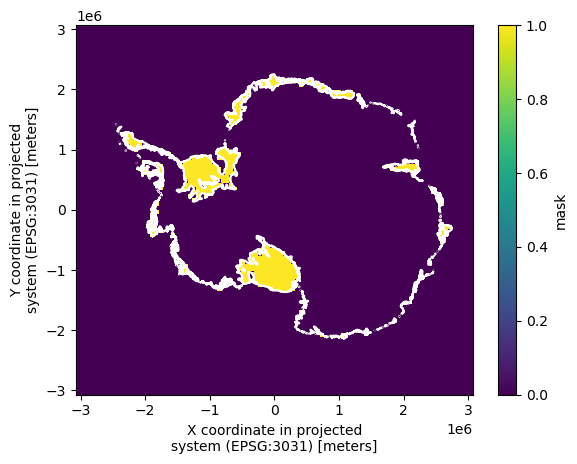

In [21]:
(shelfmask_other).plot()
shelfmask.plot.contour(levels = [-0.5, 0.5, 1.5], colors=['white'])